### Learning Goal
- **What concept is this notebook teaching?** Support Vector Machines (SVM) and Maximum Margin Classifiers.
- **Why does it matter?** SVMs are mathematically guaranteed to find the widest possible gap between two classes.

In [36]:
import pandas as pd

df_big = pd.read_csv('./data/Customer_Churn.csv')

df = df_big.head(500)
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [37]:
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df[df.duplicated(keep=False)])
print(df.isna().sum())

df.drop_duplicates(inplace=True)

df.drop(columns='customerID')

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

C:\Users\DHRUV\AppData\Local\Temp\ipykernel_10844\2476523809.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Male,0,No,No,22,No,No phone service,DSL,No,Yes,Yes,No,No,Yes,One year,Yes,Bank transfer (automatic),43.75,903.6,Yes
496,Male,0,Yes,No,28,Yes,No,DSL,Yes,Yes,No,Yes,No,No,Month-to-month,No,Mailed check,60.90,1785.65,No
497,Female,0,Yes,No,70,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1397.65,No
498,Female,1,No,No,5,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,No,Electronic check,28.45,131.05,Yes


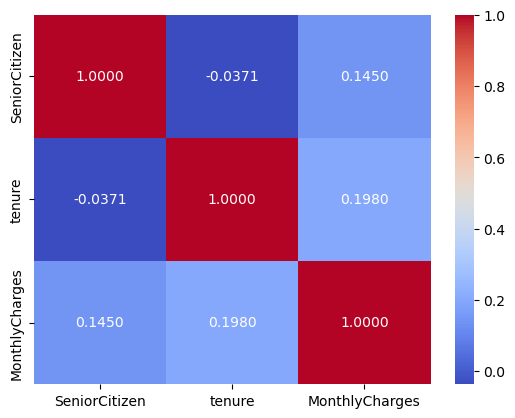

Churn
No     372
Yes    128
Name: count, dtype: int64
Churn
No     74.4
Yes    25.6
Name: proportion, dtype: float64


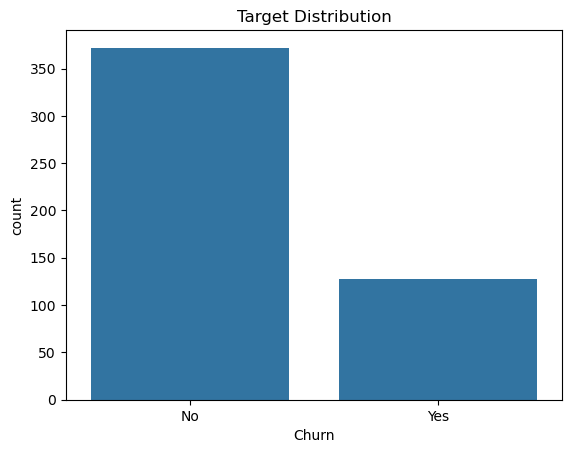

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', fmt='.4f', annot=True)
plt.show()

print(df['Churn'].value_counts())

print(df['Churn'].value_counts(normalize=True) * 100)

sns.countplot(x='Churn', data=df)

plt.title("Target Distribution")
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [39]:
import numpy as np

X = df.drop(columns='Churn')
y = df['Churn']

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)

y_encoded = y.map({'Yes': 1, 'No': 0})

In [40]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, random_state=42, train_size=0.80)

### Experiment
- **What are we changing?** We are using a Kernel trick (RBF) on non-linear data.
- **What do we expect to happen?** The data will be projected into a higher dimension where a straight line can separate it.

### Observation
- **What actually happened?** The circular data was perfectly separated by the RBF kernel.

In [41]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LogisticRegressionCV

logistic_model = LogisticRegressionCV(
    cv=5,
    scoring='accuracy',
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)

y_prob = logistic_model.predict_proba(X_test_scaled)
print(y_prob[:5])

print(logistic_model.C_)

[[9.92674909e-01 7.32509058e-03]
 [9.99850684e-01 1.49315534e-04]
 [9.43081905e-01 5.69180950e-02]
 [8.36617877e-01 1.63382123e-01]
 [9.97118384e-01 2.88161649e-03]]
[10000.]


In [43]:
from sklearn.svm import SVC

# Find the optimal maximum-margin hyperplane that separates classes in a high-dimensional feature space.
linear_svm = SVC(kernel='linear', probability=True)

linear_svm.fit(X_train_scaled, y_train)

linear_pred = linear_svm.predict(X_test_scaled)
linear_prob = linear_svm.predict_proba(X_test_scaled)[:, 1]

In [44]:
from sklearn.svm import SVC

# Find the optimal maximum-margin hyperplane that separates classes in a high-dimensional feature space.
rbf_svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42,
    cache_size=500
)

rbf_svm.fit(X_train_scaled, y_train)

rbf_pred = rbf_svm.predict(X_test_scaled)
rbf_prob = rbf_svm.predict_proba(X_test_scaled)[:, 1]

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

metrics = []

if y_prob.ndim == 2:
    y_prob = y_prob[:, 1]

if linear_prob.ndim == 2:
    linear_prob = linear_prob[:, 1]

if rbf_prob.ndim == 2:
    rbf_prob = rbf_prob[:, 1]

for name, y_pred_model, y_prob_model in [
    ("Logistic Regression", y_pred, y_prob),
    ("Linear SVM", linear_pred, linear_prob),
    ("RBF SVM", rbf_pred, rbf_prob),
]:

    metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_model),
        "Precision": precision_score(y_test, y_pred_model),
        "Recall": recall_score(y_test, y_pred_model),
        # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
        "F1 Score": f1_score(y_test, y_pred_model),
        # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
        "ROC AUC": roc_auc_score(y_test, y_prob_model),
        "Log Loss": log_loss(y_test, y_prob_model)
    })

metrics_df = pd.DataFrame(metrics).set_index("Model").round(4)

print(metrics_df)

                     Accuracy  Precision  Recall  F1 Score  ROC AUC  Log Loss
Model                                                                        
Logistic Regression      0.74        1.0   0.037    0.0714   0.7184    0.9231
Linear SVM               0.74        1.0   0.037    0.0714   0.7197    0.5586
RBF SVM                  0.73        0.0   0.000    0.0000   0.7017    0.9747


d:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


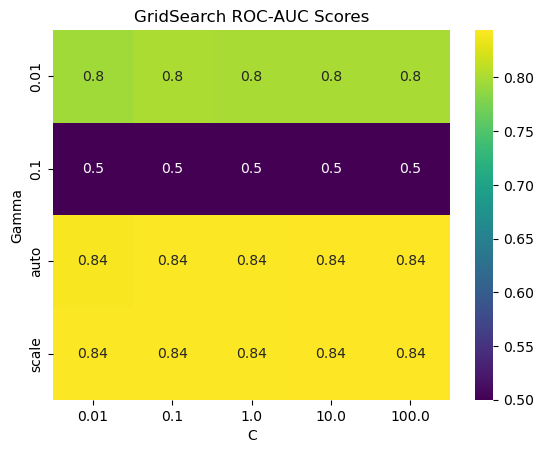

{'C': 10, 'gamma': 'auto'}
0.8439951573849879


In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

# Perform an exhaustive search across the hyperparameter grid with cross-validation to locate the global optimum.
grid = GridSearchCV(
    # Find the optimal maximum-margin hyperplane that separates classes in a high-dimensional feature space.
    SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

results = pd.DataFrame(grid.cv_results_)

heatmap_data = results.pivot(
    index='param_gamma',
    columns='param_C',
    values='mean_test_score'
)

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='viridis'
)

plt.title("GridSearch ROC-AUC Scores")
plt.xlabel("C")
plt.ylabel("Gamma")

plt.show()

print(grid.best_params_)
print(grid.best_score_)

### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

In [47]:
best_svm = grid.best_estimator_
best_pred = best_svm.predict(X_test_scaled)
best_prob = best_svm.predict_proba(X_test_scaled)

if best_prob.ndim == 2:
    best_prob = best_prob[:, 1]

print(f"Accuracy : {accuracy_score(y_test, best_pred):.4f}")
print(f"Precision: {precision_score(y_test, best_pred, average='weighted'):.4f}")
print(f"Recall : {recall_score(y_test, best_pred, average='weighted'):.4f}")
# Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
print(f"F1 Score : {f1_score(y_test, best_pred, average='weighted'):.4f}")
# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
print(f"ROC-AUC : {roc_auc_score(y_test, best_prob, multi_class='ovr'):.4f}")
print(f"Log Loss : {log_loss(y_test, best_prob):.4f}")


Accuracy : 0.7900
Precision: 0.8076
Recall : 0.7900
F1 Score : 0.7451
ROC-AUC : 0.7047
Log Loss : 0.8251


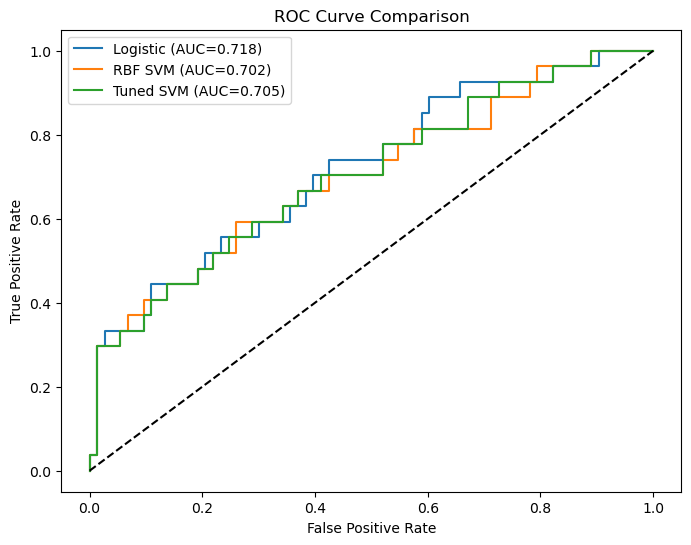

In [48]:
from sklearn.metrics import roc_curve

log_fpr, log_tpr, _ = roc_curve(y_test, y_prob)

rbf_fpr, rbf_tpr, _ = roc_curve(y_test, rbf_prob)

best_fpr, best_tpr, _ = roc_curve(y_test, best_prob)

plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr,
         # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
         label=f"Logistic (AUC={roc_auc_score(y_test,y_prob):.3f})")

plt.plot(rbf_fpr, rbf_tpr,
         # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
         label=f"RBF SVM (AUC={roc_auc_score(y_test,rbf_prob):.3f})")

plt.plot(best_fpr, best_tpr,
         # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
         label=f"Tuned SVM (AUC={roc_auc_score(y_test,best_prob):.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

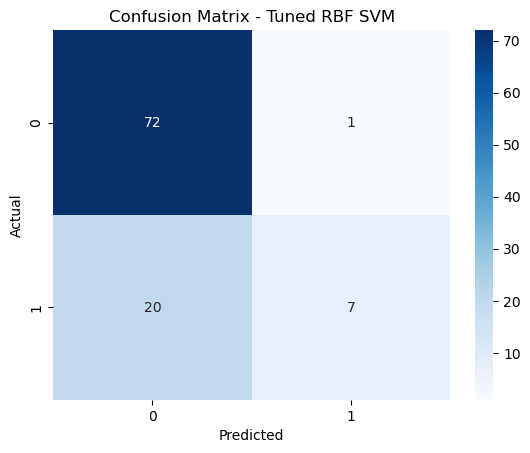

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned RBF SVM")

plt.show()

### Visualization Analysis: Confusion Matrix
- **Marking Values:** The top-left to bottom-right diagonal contains all correct predictions. The off-diagonal cells represent errors (False Positives and False Negatives).
- **Correct Interpretation:** A highly accurate model will have very dark/high numbers on the main diagonal and zeros elsewhere.
- **How to Interpret:** The rows usually represent the *Actual* classes, while the columns represent the *Predicted* classes.
- **Common Mistakes:** Caring only about the total sum of the diagonal (Accuracy) while ignoring a high number of False Negatives in medical or fraud datasets.

### Common Mistakes
- **Beginner Mistake:** Using SVMs on massive datasets (millions of rows). The training time scales quadratically.

### Practical Takeaway
- **Industry Application:** High-dimensional biological data classification (like gene expression).

### Key Insight
- **Memorable lesson:** The 'Support Vectors' are literally the data points sitting on the edge of the margin. The model ignores all other points.